In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, f1_score, classification_report
import timm

# ------------------------
# CONFIG
# ------------------------
DATA_ROOT = "BTMK"    # folder containing train/val
MODEL_NAME = "vit_tiny_patch16_224"  # can change to vit_base_patch16_224
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LR = 3e-4
WEIGHT_DECAY = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_PATH = "best_vit.pth"

# ------------------------
# TRANSFORMS
# ------------------------
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5]),
])

# ------------------------
# DATALOADERS
# ------------------------
train_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_ROOT, "val"), val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

NUM_CLASSES = len(train_ds.classes)
print("Classes:", train_ds.classes)

# ------------------------
# MODEL: ViT from timm
# ------------------------
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
).to(DEVICE)

# ------------------------
# LOSS & OPTIMIZER
# ------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ------------------------
# TRAIN FUNCTION
# ------------------------
def train_one_epoch():
    model.train()
    total, correct, loss_sum = 0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return loss_sum / total, correct / total

# ------------------------
# EVAL FUNCTION
# ------------------------
def evaluate():
    model.eval()
    total, correct, loss_sum = 0, 0, 0
    preds, labels_list = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            loss_sum += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

            preds.extend(outputs.argmax(1).cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_list, preds)
    f1 = f1_score(labels_list, preds, average="macro")
    return loss_sum / total, acc, f1, preds, labels_list


# ------------------------
# TRAINING LOOP
# ------------------------
best_acc = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc, val_f1, preds, labels_list = evaluate()
    scheduler.step()

    print(f"Epoch {epoch}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        print("Saved best model.")


print("\nFinal Classification Report:")
print(classification_report(labels_list, preds, target_names=train_ds.classes))

print(f"\nBest Validation Accuracy: {best_acc:.4f}")


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Epoch 1/20 | Train Acc: 0.8260 | Val Acc: 0.9373 | F1: 0.9343
Saved best model.
Epoch 2/20 | Train Acc: 0.9424 | Val Acc: 0.9591 | F1: 0.9576
Saved best model.
Epoch 3/20 | Train Acc: 0.9538 | Val Acc: 0.9601 | F1: 0.9590
Saved best model.
Epoch 4/20 | Train Acc: 0.9632 | Val Acc: 0.9601 | F1: 0.9590
Epoch 5/20 | Train Acc: 0.9662 | Val Acc: 0.9724 | F1: 0.9716
Saved best model.
Epoch 6/20 | Train Acc: 0.9782 | Val Acc: 0.9781 | F1: 0.9776
Saved best model.
Epoch 7/20 | Train Acc: 0.9748 | Val Acc: 0.9582 | F1: 0.9561
Epoch 8/20 | Train Acc: 0.9809 | Val Acc: 0.9658 | F1: 0.9647
Epoch 9/20 | Train Acc: 0.9896 | Val Acc: 0.9838 | F1: 0.9835
Saved best model.
Epoch 10/20 | Train Acc: 0.9933 | Val Acc: 0.9724 | F1: 0.9715
Epoch 11/20 | Train Acc: 0.9917 | Val Acc: 0.9895 | F1: 0.9890
Saved best model.
Epoch 12/20 | Train Acc: 0.9969 | Val Acc: 0.9876 | F1: 0.9871
Epoch 13/20 | Train Acc: 0.9945 | Val Acc: 0.9905 | F1: 0.9902
Saved 

In [2]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report
import timm

# ------------------------
# CONFIG
# ------------------------
DATA_ROOT = "BTMK"                     # root folder
TEST_DIR = os.path.join(DATA_ROOT, "test")
MODEL_NAME = "vit_tiny_patch16_224"   # must match trained model
IMG_SIZE = 224
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "best_vit.pth"           # saved model

# ------------------------
# TEST TRANSFORMS
# ------------------------
test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5]),
])

# ------------------------
# LOAD TEST DATA
# ------------------------
test_ds = datasets.ImageFolder(TEST_DIR, test_tf)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

NUM_CLASSES = len(test_ds.classes)
print("Classes:", test_ds.classes)

# ------------------------
# LOAD MODEL
# ------------------------
model = timm.create_model(
    MODEL_NAME,
    pretrained=False,            # VERY IMPORTANT — don't load pretrained here
    num_classes=NUM_CLASSES
).to(DEVICE)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

criterion = nn.CrossEntropyLoss()

# ------------------------
# EVAL LOOP
# ------------------------
all_preds = []
all_labels = []
total_loss = 0
total = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        total += labels.size(0)

        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ------------------------
# METRICS
# ------------------------
test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="macro")

print("\n================ TEST RESULTS ================")
print(f"Test Loss: {total_loss / total:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro F1-score: {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=test_ds.classes))


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

================ TEST RESULTS ================
Test Loss: 0.0565
Test Accuracy: 0.9886
Test Macro F1-score: 0.9881

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.98      0.99       244
  meningioma       0.98      0.98      0.98       248
     notumor       1.00      1.00      1.00       300
   pituitary       0.99      0.99      0.99       265

    accuracy                           0.99      1057
   macro avg       0.99      0.99      0.99      1057
weighted avg       0.99      0.99      0.99      1057



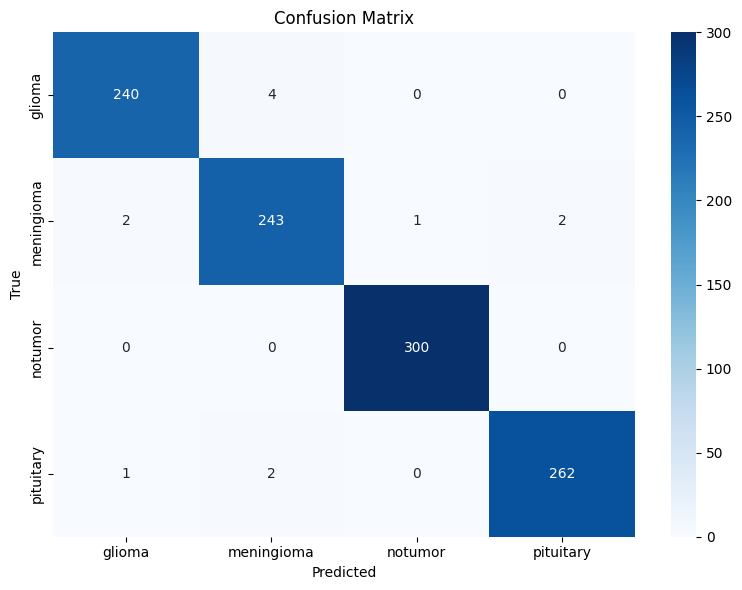

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
classes = test_ds.classes  # class names

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
